# 01 · Finding exoplanets by hand

Before automating anything, this notebook walks through a full transit search **by hand** on two stars whose planets are already known. If the method can't recover known planets, it can't be trusted on unknown ones.

| Star | Planet | Why it's here |
|---|---|---|
| **WASP-18** | WASP-18 b, a hot Jupiter | The easy case: a ~1% transit visible by eye |
| **Pi Mensae** | Pi Mensae c, a super-Earth | The hard case: a ~0.03% transit invisible in the raw data |

**The method:** download a light curve (the star's brightness over time) → detrend it → search for repeating dips with Box Least Squares (BLS) → fold the data at the detected period → measure the planet.

Along the way, two things go wrong, and fixing them teaches the main lessons that the automated pipeline (`src/pipeline.py`) is built on.

## Setup

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message=".*oktopus.*")

import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

---
# Part 1: WASP-18 b (the easy case)

## 1. Find and download the data

We use NASA's official **SPOC** light curves at **2-minute cadence**: one brightness measurement every 2 minutes, with the worst spacecraft systematics already removed (the `pdcsap_flux` column). Each TESS **sector** covers about 27 days.

In [2]:
search = lk.search_lightcurve("WASP-18", mission="TESS", author="SPOC", exptime=120)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,100100827,0.0
1,TESS Sector 03,2018,SPOC,120,100100827,0.0
2,TESS Sector 29,2020,SPOC,120,100100827,0.0
3,TESS Sector 30,2020,SPOC,120,100100827,0.0
4,TESS Sector 69,2023,SPOC,120,100100827,0.0
5,TESS Sector 96,2025,SPOC,120,100100827,0.0
6,TESS Sector 103,2026,SPOC,120,100100827,0.0
7,TESS Sector 104,2026,SPOC,120,100100827,0.0
8,TESS Sector 105,2026,SPOC,120,100100827,0.0


In [3]:
lc = search[0].download()      # Sector 2, 2018
lc

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1354.1115072617192,4.7745688e+04,2.5922741e+01,3.2845002e-03,91190,1638.57401,468.04924,4.5699730e+04,2.4585836e+01,2.1270193e+03,7.5499601e+00,4.7745688e+04,2.5922741e+01,0,———,———,———,———,1638.57401,5.5316015e-04,468.04924,5.7710981e-04,-1.2000147e-01,7.8144908e-02
1354.1128961919705,4.7782176e+04,2.5922379e+01,3.2845421e-03,91191,1638.58778,468.04160,4.5753094e+04,2.4585493e+01,2.1165220e+03,7.5075278e+00,4.7782176e+04,2.5922379e+01,0,———,———,———,———,1638.58778,5.5368309e-04,468.04160,5.7716778e-04,-1.0294508e-01,6.7404680e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381.5160700871054,4.7736797e+04,2.6382429e+01,3.6914879e-03,110921,1638.68720,467.98565,4.5928766e+04,2.5021816e+01,2.8539685e+03,8.2591190e+00,4.7736797e+04,2.6382429e+01,0,———,———,———,———,1638.68720,5.6814571e-04,467.98565,5.8693311e-04,1.8965174e-02,3.1502221e-03
1381.51745897754,4.7728082e+04,2.6386803e+01,3.6914900e-03,110922,1638.68472,467.98903,4.5919125e+04,2.5025965e+01,2.8711174e+03,8.2647591e+00,4.7728082e+04,2.6386803e+01,0,———,———,———,———,1638.68472,5.6839891e-04,467.98903,5.8714236e-04,1.6774995e-02,7.3410203e-03


## 2. Look at the raw light curve

`remove_nans()` drops missing measurements (we drop them rather than fill them in, because invented values could paint over a transit). `normalize()` scales the brightness so the star's typical level is 1.0, making a value of 0.99 a 1% dip.

The regular downward spikes, about a day apart, are WASP-18 b passing in front of its star. The gap in the middle is the spacecraft pausing to send data to Earth.

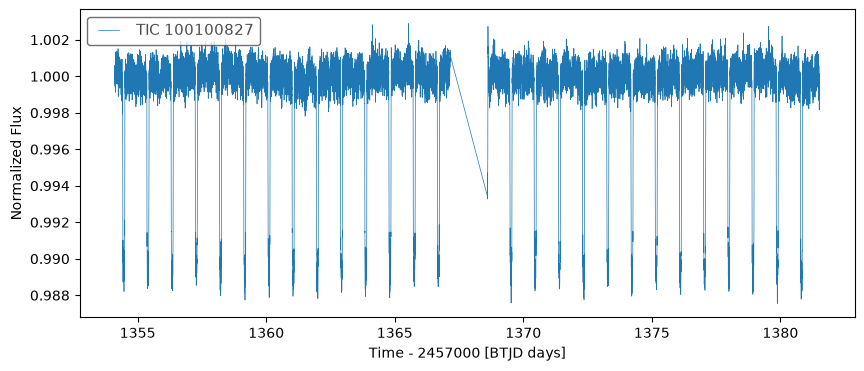

In [4]:
lc = lc.remove_nans().normalize()

fig, ax = plt.subplots(figsize=(10, 4))
lc.plot(ax=ax)
plt.show()

Zooming in on the first three days shows individual transits. Each has steep sides (the planet sliding onto and off the star) and a rounded bottom. The rounding is **limb darkening**: a star's edge looks dimmer than its centre, so the planet blocks slightly less light near the edge.

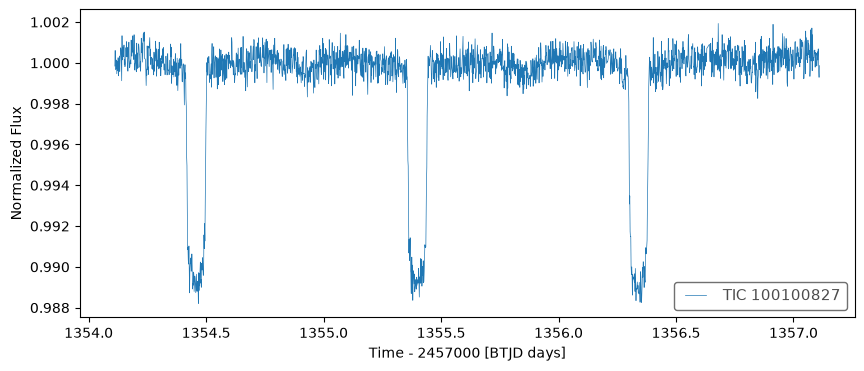

In [5]:
t = lc.time.value
zoom = lc[(t >= t[0]) & (t <= t[0] + 3)]

fig, ax = plt.subplots(figsize=(10, 4))
zoom.plot(ax=ax)
plt.show()

## 3. Detrend (first attempt)

Stars and instruments drift slowly in brightness. `flatten()` fits a smooth curve through the data with a sliding window and divides it out, leaving the short transits behind. The window here is 901 points, about 30 hours: much longer than a 2-hour transit.

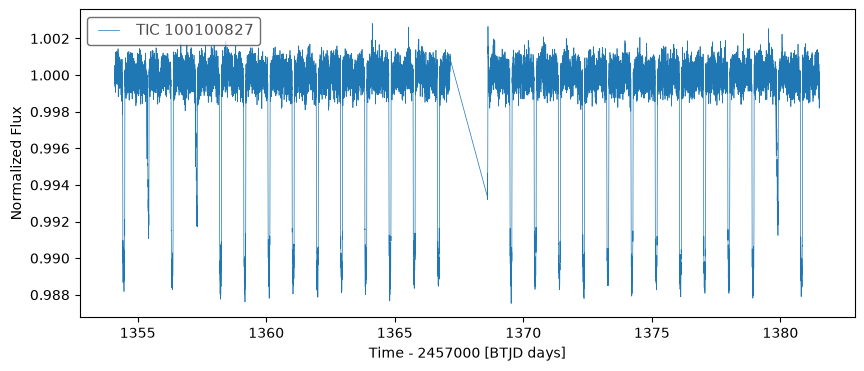

In [6]:
flat = lc.flatten(window_length=901)

fig, ax = plt.subplots(figsize=(10, 4))
flat.plot(ax=ax)
plt.show()

## 4. Search for the period with Box Least Squares

**BLS** is a classical search algorithm, not machine learning. For each trial period and duration, it folds the light curve and fits a box-shaped dip, measuring how much better that fits than no dip at all. The result is a **periodogram**: detection strength for every trial period.

The tallest peak is the planet. The smaller peaks at 2×, 3×, ½× the period are **aliases**: folding at a multiple or fraction of the true period still lines up some of the transits. A real periodic signal always produces this family of peaks.

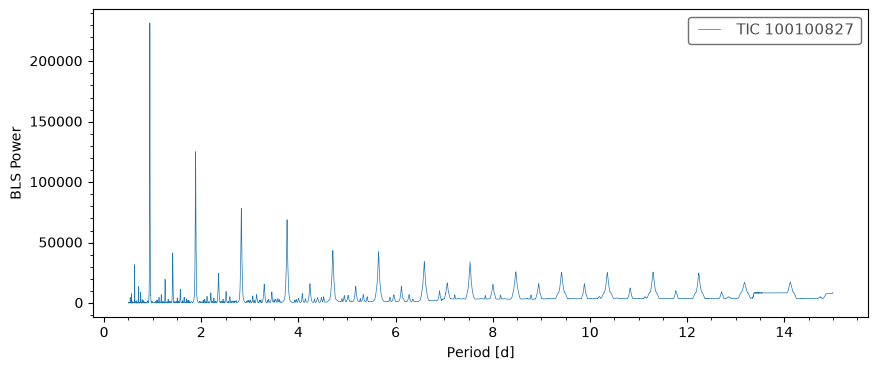

Best period: 0.94155 d


In [7]:
periods = np.linspace(0.5, 15, 20000)
durations = [0.04, 0.06, 0.08, 0.1, 0.15] # days: about 1 to 3.6 hours
bls = flat.to_periodogram(method="bls", period=periods, duration=durations)

fig, ax = plt.subplots(figsize=(10, 4))
bls.plot(ax=ax)
plt.show()

print(f"Best period: {bls.period_at_max_power:.5f}")

## 5. Refine the period (coarse-to-fine)

The first grid's steps were about 0.0007 days, so its answer is limited by the grid. A second, much denser search around the peak pins the period down.

In [8]:
fine_periods = np.linspace(0.93, 0.95, 5000)
fine_durations = np.linspace(0.06, 0.12, 13)
bls_fine = flat.to_periodogram(method="bls", period=fine_periods, duration=fine_durations)

period = bls_fine.period_at_max_power
t0 = bls_fine.transit_time_at_max_power
duration = bls_fine.duration_at_max_power

print(f"Period: {period:.5f} (published: ~0.94145 d)")
print(f"Duration: {duration:.3f} (BLS's box shape underestimates real durations)")

Period: 0.94153 d (published: ~0.94145 d)
Duration: 0.078 d (BLS's box shape underestimates real durations)


## 6. Fold, and a problem appears

**Folding** stacks every transit on top of the others by converting time into "time since the nearest mid-transit." The red line averages the points in small bins.

The transit shape looks right, **but there is a diagonal streak of points** cutting across the dip. Some transits came out shallower than others.

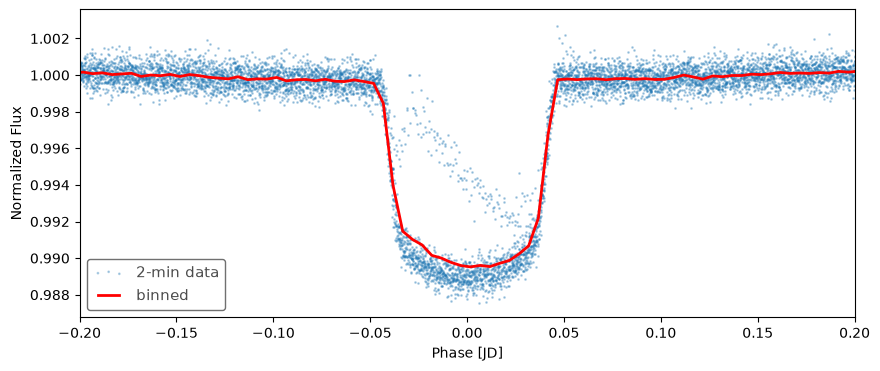

In [9]:
folded = flat.fold(period=period, epoch_time=t0)

fig, ax = plt.subplots(figsize=(10, 4))
folded.scatter(ax=ax, alpha=0.3, label="2-min data")
folded.bin(time_bin_size=0.005).plot(ax=ax, color="red", lw=2, label="binned")
ax.set_xlim(-0.2, 0.2)
plt.show()

**Finding the cause.** Comparing one transit before and after detrending shows that `flatten()` partly **erased** it. Near a data gap, the smoothing curve has fewer points to anchor it, so it bends down into the transit, and dividing by it pushes the transit back up.

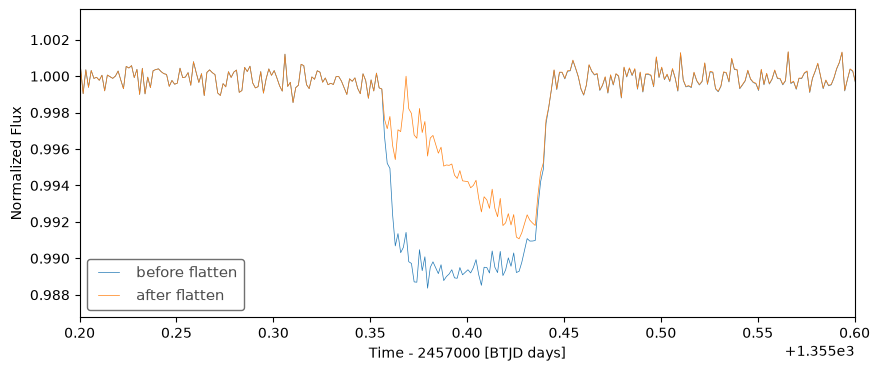

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
lc.plot(ax=ax, label="before flatten")
flat.plot(ax=ax, label="after flatten")
ax.set_xlim(1355.2, 1355.6)
plt.show()

## 7. The fix: mask the transits, then detrend again

Now that BLS has found the transits, we can tell `flatten()` to **ignore** them when fitting the smooth curve, so it bridges across each transit instead of bending into it. The mask is 0.12 days wide, a little wider than the real ~0.09-day transit, for safety.

This **two-pass** approach (detrend, find, mask, detrend again) is built into the automated pipeline. The streak disappears:

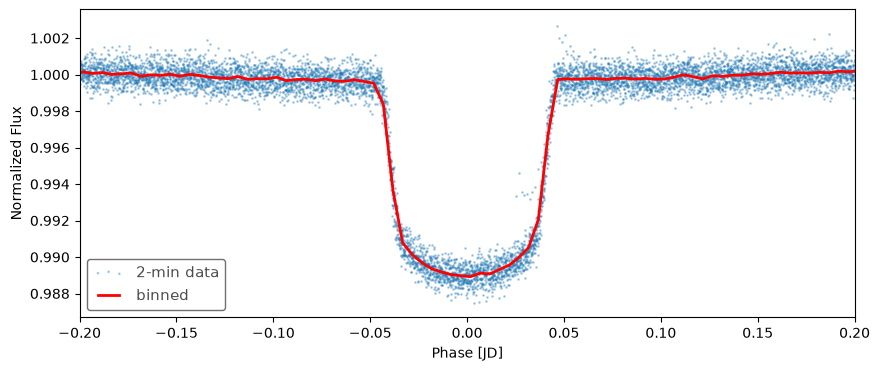

In [11]:
mask = bls_fine.get_transit_mask(period=period, transit_time=t0, duration=0.12)
flat = lc.flatten(window_length=901, mask=mask)

folded = flat.fold(period=period, epoch_time=t0)
fig, ax = plt.subplots(figsize=(10, 4))
folded.scatter(ax=ax, alpha=0.3, label="2-min data")
folded.bin(time_bin_size=0.005).plot(ax=ax, color="red", lw=2, label="binned")
ax.set_xlim(-0.2, 0.2)
plt.show()

## 8. Measure the planet

The fraction of light blocked equals the fraction of the star's disk the planet covers: **depth ≈ (R_planet / R_star)²**. So R_planet = √depth × R_star.

The result comes out slightly above the published ~1.2 Jupiter radii, as expected: limb darkening makes the centre of the transit a little deeper than the simple formula assumes.

In [12]:
t_fold = folded.time.value
depth_meas = 1 - np.median(folded[np.abs(t_fold) < 0.02].flux.value) # central ~1 hour

r_star_sun = 1.23 # WASP-18's radius (solar radii, published)
rp_jup = np.sqrt(depth_meas) * r_star_sun * 9.73  # 1 solar radius ≈ 9.73 Jupiter radii

print(f"Depth: {depth_meas*100:.2f}%")
print(f"Planet radius: {rp_jup:.2f} Jupiter radii (published: ~1.2)")

Depth: 1.09%
Planet radius: 1.25 Jupiter radii (published: ~1.2)


---
# Part 2: Pi Mensae c (the hard case)

Pi Mensae c is about twice Earth's size, so its transit is only about **0.03% deep**, roughly 30 times shallower than WASP-18 b's and smaller than the noise in any single measurement. Three sectors are stitched together to collect more transits.

## 9. Download three sectors

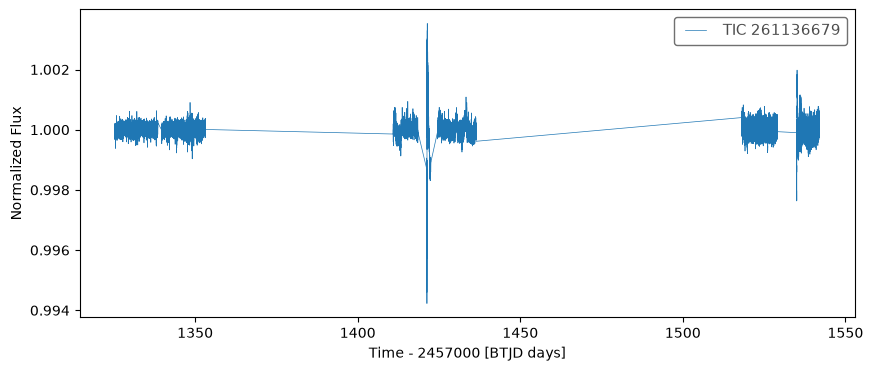

In [13]:
search_pi = lk.search_lightcurve("pi Men", mission="TESS", author="SPOC", exptime=120)
lc_pi = search_pi[:3].download_all().stitch().remove_nans()

fig, ax = plt.subplots(figsize=(10, 4))
lc_pi.plot(ax=ax)
plt.show()

The transits are invisible. But there are two large **glitches**, near days 1421 and 1535. Both sectors had interruptions, and when a camera restarts, the detector produces spikes and ramps as it settles.

## 10. A false detection

Searching the data **as it is** shows why that matters:

Best period: 13.777 d   depth: 0.00110


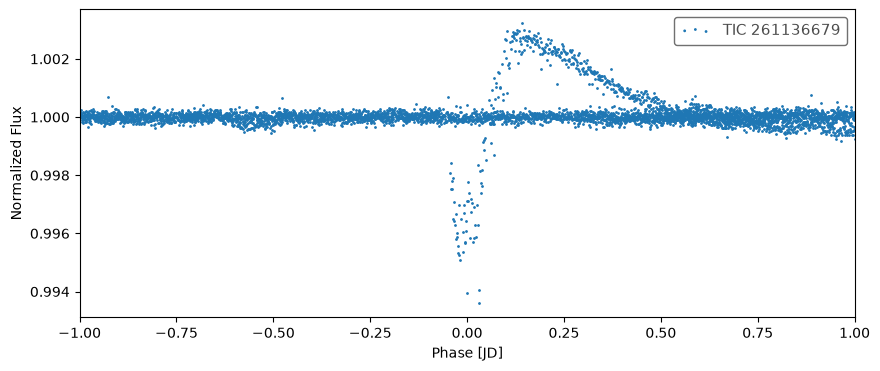

In [14]:
flat_raw = lc_pi.flatten(window_length=901)
bls_raw = flat_raw.to_periodogram(method="bls", period=np.linspace(1, 15, 30000),duration=[0.08, 0.1, 0.12, 0.15, 0.2])
print(f"Best period: {bls_raw.period_at_max_power:.3f}   depth: {bls_raw.depth_at_max_power:.5f}")

fig, ax = plt.subplots(figsize=(10, 4))
flat_raw.fold(period=bls_raw.period_at_max_power,
              epoch_time=bls_raw.transit_time_at_max_power).scatter(ax=ax)
ax.set_xlim(-1, 1)
plt.show()

BLS reports about **13.8 days**, nearly four times too deep for this planet, and the fold shows why: it's a single glitch, a sharp dip followed by a brightening ramp. A planet can only block light, never add it, and real transits are symmetric.

**Lesson: BLS always returns a "best" answer, even when there's nothing real there.** Bad data has to be removed, and results have to be checked.

## 11. Inspect and remove the glitches

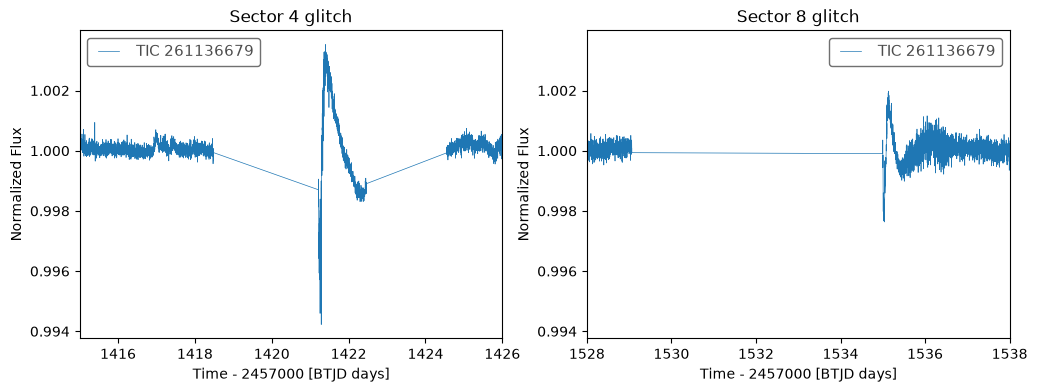

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lc_pi.plot(ax=axes[0]); axes[0].set_xlim(1415, 1426); axes[0].set_title("Sector 4 glitch")
lc_pi.plot(ax=axes[1]); axes[1].set_xlim(1528, 1538); axes[1].set_title("Sector 8 glitch")
plt.show()

Kept 43870 of 45841 points


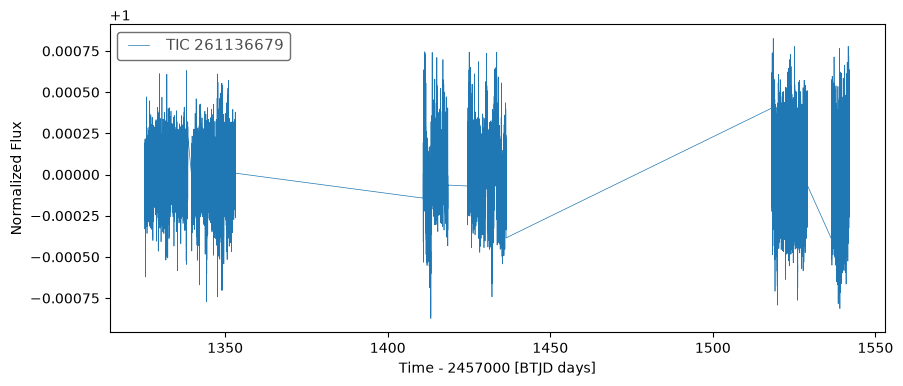

In [16]:
t = lc_pi.time.value
bad = ((t > 1419) & (t < 1424)) | ((t > 1529.5) & (t < 1536.5))
lc_pi_clean = lc_pi[~bad].remove_outliers(sigma=5) # 5-sigma clip
print(f"Kept {len(lc_pi_clean)} of {len(lc_pi)} points")

fig, ax = plt.subplots(figsize=(10, 4))
lc_pi_clean.plot(ax=ax)
plt.show()

Here the glitch windows were chosen by eye. The automated pipeline does this automatically instead, by trimming the start of every data segment and only clipping **upward** outliers, so deep transits are never removed.

## 12. Search the cleaned data

Now the tallest peak is at **~6.27 days**: Pi Mensae c. Every other significant peak is an alias of it (½×, 2×, ⅓×, and so on).

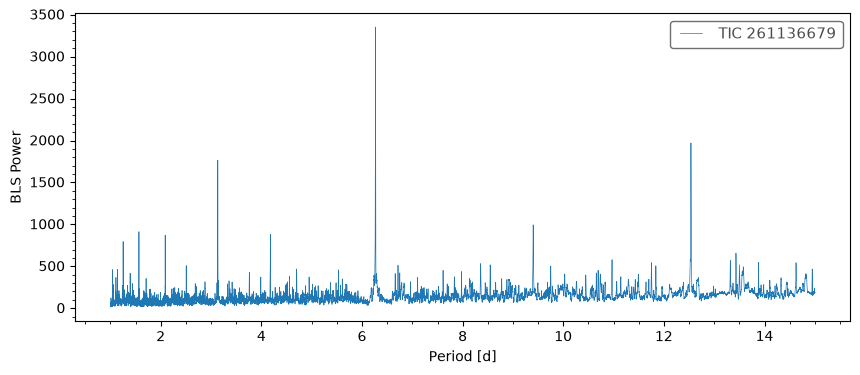

Best period: 6.2679 d (published: ~6.27 d)


In [17]:
flat_pi = lc_pi_clean.flatten(window_length=901)
bls_pi = flat_pi.to_periodogram(method="bls", period=np.linspace(1, 15, 30000), duration=[0.08, 0.1, 0.12, 0.15, 0.2])

fig, ax = plt.subplots(figsize=(10, 4))
bls_pi.plot(ax=ax)
plt.show()

print(f"Best period: {bls_pi.period_at_max_power:.4f} (published: ~6.27 d)")

## 13. Refine, mask, and fold

The same steps that worked for WASP-18: a fine search, then detrending again with the transits masked. Individual points look like pure noise; the binned red line reveals the dip, emerging from averaging dozens of transits.

Period: 6.26793 d


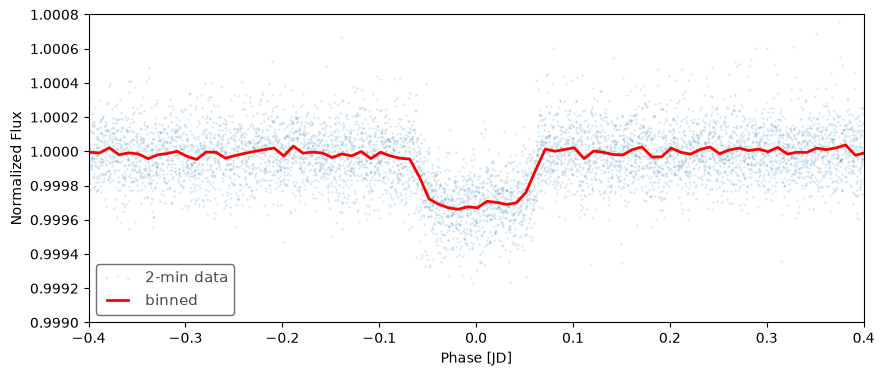

In [18]:
fine_p = np.linspace(6.2, 6.35, 5000)
bls_pi_fine = flat_pi.to_periodogram(method="bls", period=fine_p,duration=np.linspace(0.08, 0.2, 13))
p_pi = bls_pi_fine.period_at_max_power
t0_pi = bls_pi_fine.transit_time_at_max_power
print(f"Period: {p_pi:.5f}")

mask_pi = bls_pi_fine.get_transit_mask(period=p_pi, transit_time=t0_pi, duration=0.25)
flat_pi = lc_pi_clean.flatten(window_length=901, mask=mask_pi)

folded_pi = flat_pi.fold(period=p_pi, epoch_time=t0_pi)
fig, ax = plt.subplots(figsize=(10, 4))
folded_pi.scatter(ax=ax, alpha=0.1, label="2-min data")
folded_pi.bin(time_bin_size=0.01).plot(ax=ax, color="red", lw=2, label="binned")
ax.set_xlim(-0.4, 0.4)
ax.set_ylim(0.9990, 1.0008)
plt.show()

## 14. Measure the planet

Depths this small are quoted in **ppm** (parts per million): 0.03% = 300 ppm.

In [19]:
t_f = folded_pi.time.value
depth_pi = 1 - np.median(folded_pi[np.abs(t_f) < 0.04].flux.value)

r_star_sun = 1.10  # Pi Mensae's radius (solar radii, published)
rp_earth = np.sqrt(depth_pi) * r_star_sun * 109.1  # 1 solar radius ≈ 109.1 Earth radii

print(f"Depth: {depth_pi*1e6:.0f} ppm (published: ~300)")
print(f"Planet radius: {rp_earth:.2f} Earth radii (published: ~2.0)")

Depth: 310 ppm (published: ~300)
Planet radius: 2.11 Earth radii (published: ~2.0)


---
# Summary

| | Measured | Published |
|---|---|---|
| WASP-18 b period | ~0.9415 d | ~0.94145 d |
| WASP-18 b radius | ~1.25 R_Jupiter | ~1.2 R_Jupiter |
| Pi Mensae c period | ~6.27 d | ~6.27 d |
| Pi Mensae c depth | ~310 ppm | ~300 ppm |
| Pi Mensae c radius | ~2.1 R_Earth | ~2.0 R_Earth |

Radii come out slightly high in both cases, consistent with limb darkening.

**Lessons carried into the automated pipeline:**

1. **Detrending can distort transits.** Find them first, mask them, and detrend again (two-pass detrending).
2. **BLS always returns an answer, even for junk.** Clean the data first, and check every result.
3. **Search coarse, then fine** to get precise periods without an enormous search grid.